> Benjamin Nikholas

> Data Science / JCSDOL-014

> Modul 3 - Tugas 14

> 16 Juli 2024
---
---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [42]:
df_titanic = sns.load_dataset('titanic')
df_titanic.head(5)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [43]:
for i in ['deck', 'age', 'embarked', 'embark_town']:
    df_titanic[i].fillna(df_titanic[i].value_counts().index[0],
                          inplace = True)
df_titanic.isna().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alive          0
alone          0
dtype: int64

In [44]:
df_titanic.replace({'male' : 0,
                    'female' : 1},
                   inplace = True)

In [45]:
X = df_titanic[['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare']]
y = df_titanic.survived

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    train_size = 0.8,
                                                    random_state = 42)

In [48]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

y_train_pred_knn = knn.predict(X_train)
y_test_pred_knn = knn.predict(X_test)

In [49]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [50]:
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)

y_train_pred = knn.predict(X_train_scaled)
y_test_pred = knn.predict(X_test_scaled)

In [58]:
print("Evaluasi pada data train:")
print(classification_report(y_train, y_train_pred))
print(f"Accuracy: {accuracy_score(y_train, y_train_pred)}")

print("\nEvaluasi pada data test:")
print(classification_report(y_test, y_test_pred))
print(f"Accuracy: {accuracy_score(y_test, y_test_pred)}")

Evaluasi pada data train:
              precision    recall  f1-score   support

           0       0.85      0.96      0.91       444
           1       0.92      0.73      0.81       268

    accuracy                           0.88       712
   macro avg       0.89      0.85      0.86       712
weighted avg       0.88      0.88      0.87       712

Accuracy: 0.875

Evaluasi pada data test:
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       105
           1       0.81      0.70      0.75        74

    accuracy                           0.81       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179

Accuracy: 0.8100558659217877


In [59]:
accuracy_scores = []
k_values = range(1, 151)
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors = k)
    knn.fit(X_train_scaled, y_train)
    y_test_pred = knn.predict(X_test_scaled)
    accuracy_scores.append(accuracy_score(y_test, y_test_pred))

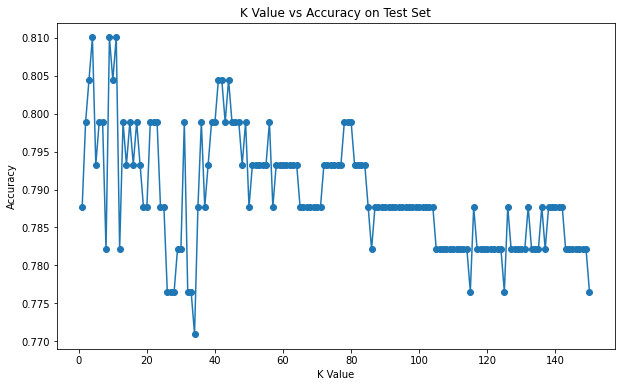

In [60]:
plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracy_scores, marker='o')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.title('K Value vs Accuracy on Test Set')
plt.show()

In [62]:
optimal_k = k_values[accuracy_scores.index(max(accuracy_scores))]
print(f"Optimal K: {optimal_k}")

knn = KNeighborsClassifier(n_neighbors = optimal_k)
knn.fit(X_train_scaled, y_train)

y_train_pred = knn.predict(X_train_scaled)
y_test_pred = knn.predict(X_test_scaled)

In [64]:
print("Evaluasi pada data train:")
print(classification_report(y_train, y_train_pred))
print(f"Accuracy: {accuracy_score(y_train, y_train_pred)}")

print("\nEvaluasi pada data test:")
print(classification_report(y_test, y_test_pred))
print(f"Accuracy: {accuracy_score(y_test, y_test_pred)}")

Evaluasi pada data train:
              precision    recall  f1-score   support

           0       0.85      0.96      0.91       444
           1       0.92      0.73      0.81       268

    accuracy                           0.88       712
   macro avg       0.89      0.85      0.86       712
weighted avg       0.88      0.88      0.87       712

Accuracy: 0.875

Evaluasi pada data test:
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       105
           1       0.81      0.70      0.75        74

    accuracy                           0.81       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179

Accuracy: 0.8100558659217877


In [65]:
dtree = DecisionTreeClassifier(random_state = 42)
dtree.fit(X_train, y_train)

y_train_pred_dtree = dtree.predict(X_train)
y_test_pred_dtree = dtree.predict(X_test)

In [67]:
train_dtree_accuracy = accuracy_score(y_train, y_train_pred_dtree).round(2)
test_dtree_accuracy = accuracy_score(y_test, y_test_pred_dtree).round(2)

print('Decision Tree Train set evaluation:')
print(f'Accuracy: {train_dtree_accuracy}')
print(classification_report(y_train, y_train_pred_dtree))
print(confusion_matrix(y_train, y_train_pred_dtree))

print('\nDecision Tree Test set evaluation:')
print(f'Accuracy: {test_dtree_accuracy}')
print(classification_report(y_test, y_test_pred_dtree))
print(confusion_matrix(y_test, y_test_pred_dtree))

Decision Tree Train set evaluation:
Accuracy: 0.89
              precision    recall  f1-score   support

           0       0.88      0.95      0.91       444
           1       0.91      0.78      0.84       268

    accuracy                           0.89       712
   macro avg       0.90      0.87      0.88       712
weighted avg       0.89      0.89      0.89       712

[[424  20]
 [ 59 209]]

Decision Tree Test set evaluation:
Accuracy: 0.81
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       105
           1       0.81      0.70      0.75        74

    accuracy                           0.81       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179

[[93 12]
 [22 52]]


In [66]:
optimal_leaf = k_values[accuracy_scores.index(max(accuracy_scores))]
print(f"Optimal leaf: {optimal_leaf}")

dtree = DecisionTreeClassifier(min_samples_leaf = optimal_leaf,
                               random_state = 42)
dtree.fit(X_train, y_train)

y_train_pred_dtree = dtree.predict(X_train)
y_test_pred_dtree = dtree.predict(X_test)

Optimal K: 4
